# 1) ResU-Net for Deblur and Denoise operations
### Using Residual U-Net to address noise and blur issues in images: network training and evaluation

## 1. Setup and Initialization
 List of imports, global variables and folders used

In [ ]:
from google.colab import drive
import os
from datasets import load_from_disk
from pathlib import Path
import sys
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import shutil

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

### --- DIRECTORIES --- ###
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/Computational Imaging")
DATASET_DIR = BASE_DIR/"dataset"
RESULT_DIR = BASE_DIR/"end_to_end_output"
LOSS_HISTORY_DIR = RESULT_DIR/"loss_history"
METRICS_DIR = RESULT_DIR/"metrics_data"
WEIGHTS_DIR = RESULT_DIR/"weights"
WEIGHTS_PATH = WEIGHTS_DIR/"resunet.pth"
RECONSTRUCTION_DIR = RESULT_DIR/"reconstruction_examples"
LOCAL_DATASET = Path("/content/dataset_local")

sys.path.append(str(BASE_DIR))

### --- HYPERPARAMETERS --- ###
BATCH_SIZE = 8
EPOCH_NUMBER = 30
LEARNING_RATE = 1e-3
PATIENCE_EARLY_STOPPING = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Loading data from the dataset
We have pre-computed and frozen the degraded inputs via a unique deterministic seed per image to ensure that all models are compared on exactly the same data, as required, rather than loading them on the fly (as is usual in EndToEnd models). This does not generate overfitting since the enormous semantic variety of dataset and the use of different noise patterns for each image force the network to learn general reconstruction rules rather than memorizing the local noise, and optimizes the computational load during execution.

In [ ]:
if not LOCAL_DATASET.exists():
    shutil.copytree(str(DATASET_DIR), str(LOCAL_DATASET))

full_dataset = load_from_disk(str(LOCAL_DATASET))

train_data = full_dataset["train"]
test_data = full_dataset["test"]
validation_data = full_dataset["validation"]

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")
print(f"Validation size: {len(validation_data)}")
#print(f"{train_data.features}")


# Conversion from arrow to tensor
class DegradedDataset(Dataset):
    def __init__(self, dataset_subset):
        self.data = dataset_subset
        self.to_tensor = transforms.ToTensor()
        self.noise_cols = ["y_005", "y_010", "y_050", "y_100"]

    def __len__(self):
        return len(self.data) * len(self.noise_cols) # We are saying that our dataset is 4 times bigger than the real one

    def __getitem__(self, idx):
        img_idx   = idx // len(self.noise_cols) # Entire division -> value updated every 4 iterations, row index
        noise_idx = idx % len(self.noise_cols) # For each row, each level of noise is selected.

        sample = self.data[img_idx]
        clean   = self.to_tensor(sample["x"].convert("RGB"))
        degraded = self.to_tensor(sample[self.noise_cols[noise_idx]].convert("RGB"))

        return  degraded, clean


train_dataset = DegradedDataset(train_data)
val_dataset = DegradedDataset(validation_data)
test_dataset = DegradedDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2, drop_last=True) # Shuffle training data at the start of each epoch to ensure randomness and prevent overfitting
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)



Train size: 4160
Test size: 520
Validation size: 520


## 3. Sanity Check (Execution is optional)
extraction of a batch of images to verify the correct correspondency between ground truth images and degraded ones and to check the correctness of dataloader overall

Clean image tensor:   torch.Size([4, 3, 256, 256])

Degraded image tensor: torch.Size([4, 3, 256, 256])



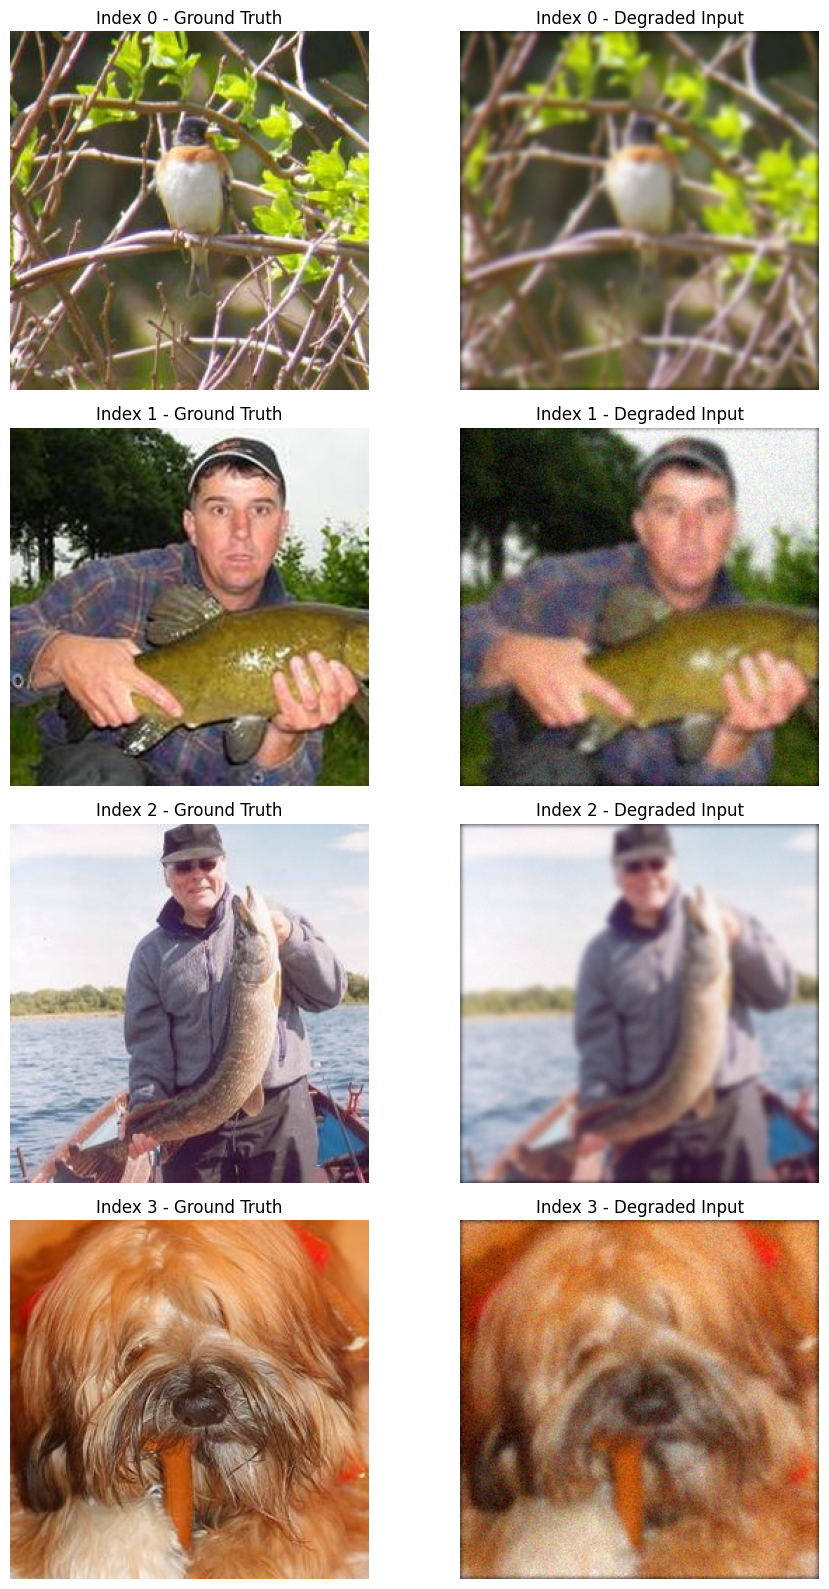

In [ ]:
data_iter = iter(train_loader)
degraded_batch, clean_batch = next(data_iter)

print(f"Clean image tensor:   {clean_batch.shape}\n")
print(f"Degraded image tensor: {degraded_batch.shape}\n")

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for i in range(4):
    img_degraded = degraded_batch[i].permute(1, 2, 0).numpy()
    img_clean    = clean_batch[i].permute(1, 2, 0).numpy()

    axes[i, 0].imshow(img_clean)
    axes[i, 0].set_title(f"Index {i} - Ground Truth")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_degraded)
    axes[i, 1].set_title(f"Index {i} - Degraded Input")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 4. ResU-Net architecture
Network Definition: Implementation of the ResUNet structure, combining the U-Net funnel shape with residual blocks

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

        if in_channels != out_channels: # Adapting shortcut's number of channels to output of convolutions
          self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
          self.shortcut = nn.Identity()

    def forward(self, x): # x: input tensor
        shortcut = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += shortcut

        out = self.relu(out)
        return out

class DownBlock(nn.Module):
      def __init__(self, in_channels, out_channels, block_type = ResidualBlock):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = block_type(in_channels, out_channels)

      def forward(self, x):
        x = self.pool(x)
        x = self.block(x)
        return x

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, block_type = ResidualBlock):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = block_type(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.block(x)



class ResUNet(nn.Module):
    def __init__(self, in_channels = 3, out_channels = 3, base_channels = 32):
        super(ResUNet, self).__init__()

        self.initial_block = ResidualBlock(in_channels, base_channels)

        self.down_block1 = DownBlock(base_channels, base_channels*2)
        self.down_block2 = DownBlock(base_channels*2, base_channels*4)
        self.down_block3 = DownBlock(base_channels*4, base_channels*8)

        self.bottleneck_block = DownBlock(base_channels*8, base_channels*16)

        self.up_block1 = UpBlock(base_channels*16, base_channels*8, base_channels*8)
        self.up_block2 = UpBlock(base_channels*8, base_channels*4, base_channels*4)
        self.up_block3 = UpBlock(base_channels*4, base_channels*2, base_channels*2)
        self.up_block4 = UpBlock(base_channels*2, base_channels, base_channels)

        self.final_block = nn.Conv2d(base_channels, out_channels, kernel_size=1)


    def forward(self, x):
        x1 = self.initial_block(x)
        x2 = self.down_block1(x1)
        x3 = self.down_block2(x2)
        x4 = self.down_block3(x3)

        out = self.bottleneck_block(x4)

        out = self.up_block1(out, x4)
        out = self.up_block2(out, x3)
        out = self.up_block3(out, x2)
        out = self.up_block4(out, x1)

        out = self.final_block(out)
        out = torch.sigmoid(out)

        return out

## 5. Training Setup
Definition of hyperparameters, loss and optimizer

## 6. Training Loop
Training loop to process data, calculate loss and update weights.

In [ ]:
def training_loop(model, w_path = WEIGHTS_PATH, num_epochs=EPOCH_NUMBER, learning_rate=LEARNING_RATE, patience_early_stopping=PATIENCE_EARLY_STOPPING):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    loss_fn = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):

        model.train()
        train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for degraded_batch, clean_batch in train_bar:
            degraded_batch, clean_batch = degraded_batch.to(device), clean_batch.to(device)

            prediction = model(degraded_batch)
            loss = loss_fn(prediction, clean_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_bar.set_postfix({'loss': f'{loss.item():.6f}'})

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for degraded_batch, clean_batch in val_loader:
                degraded_batch, clean_batch = degraded_batch.to(device), clean_batch.to(device)

                prediction = model(degraded_batch)
                loss = loss_fn(prediction, clean_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)


        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), w_path)
            epochs_no_improve = 0
            tqdm.write(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} [BEST MODEL SAVED]")
        else:
            epochs_no_improve += 1
            tqdm.write(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} [No improvement since{epochs_no_improve} epochs]")


        if epochs_no_improve >= patience_early_stopping:
            tqdm.write(f"\n Early Stopping activated. No improvement on validation loss since {patience_early_stopping} epochs.")
            print("Training finished")
            break


    reloaded_model = type(model)()
    reloaded_model.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu', weights_only=True))
    reloaded_model = reloaded_model.to(device).eval()


    history_file_path = LOSS_HISTORY_DIR / f"history.json"


    try:
        with open(history_file_path, 'w') as f:

              json.dump(history, f, indent=4)
        tqdm.write(f"[INFO] History saved in: {history_file_path}")
    except Exception as e:
          tqdm.write(f"[ERROR]: {e}")

    return reloaded_model, history

torch.manual_seed(0)
ResU_Net, history = training_loop(ResUNet())

Epoch 1/30 [Train]:   0%|          | 0/2080 [00:00<?, ?it/s]

Epoch 1/30 -> Train Loss: 0.005081 | Val Loss: 0.004027 [BEST MODEL SAVED]


Epoch 2/30 [Train]:   0%|          | 0/2080 [00:00<?, ?it/s]

Epoch 2/30 -> Train Loss: 0.003612 | Val Loss: 0.003495 [BEST MODEL SAVED]


Epoch 3/30 [Train]:   0%|          | 0/2080 [00:00<?, ?it/s]

...

Epoch 28/30 -> Train Loss: 0.002597 | Val Loss: 0.002709 [No improvement since1 epochs]


Epoch 29/30 [Train]:   0%|          | 0/2080 [00:00<?, ?it/s]

Epoch 29/30 -> Train Loss: 0.002592 | Val Loss: 0.002749 [No improvement since2 epochs]


Epoch 30/30 [Train]:   0%|          | 0/2080 [00:00<?, ?it/s]

Epoch 30/30 -> Train Loss: 0.002592 | Val Loss: 0.002739 [No improvement since3 epochs]


## 7. Metric-based evaluation
Evaluating the best network weights based on objective metrics:

In [3]:
def evaluate_model(model, test_data, device=device):
    model.eval()
    to_tensor = transforms.ToTensor()
    noise_cols = ["y_005", "y_010", "y_050", "y_100"]

    results = {col: {"psnr": [], "ssim": []} for col in noise_cols}

    print("Starting evaluation...")

    with torch.no_grad():
        for i in range(len(test_data)):
            sample = test_data[i]

            clean = to_tensor(sample["x"].convert("RGB"))

            for col in noise_cols:
                degraded = to_tensor(sample[col].convert("RGB"))
                input_tensor = degraded.unsqueeze(0).to(device)
                output = model(input_tensor).squeeze(0).cpu().clamp(0, 1)
                out_np = output.permute(1, 2, 0).numpy()
                clean_np = clean.permute(1, 2, 0).numpy()
                results[col]["psnr"].append(psnr(clean_np, out_np, data_range=1.0))

                try:
                    current_ssim = ssim(clean_np, out_np, data_range=1.0, channel_axis=2)
                except TypeError:
                    current_ssim = ssim(clean_np, out_np, data_range=1.0, multichannel=True)

                results[col]["ssim"].append(current_ssim)

    summary = {}
    for col in noise_cols:
        summary[col] = {
            "psnr_mean": np.mean(results[col]["psnr"]),
            "psnr_std":  np.std(results[col]["psnr"]),
            "ssim_mean": np.mean(results[col]["ssim"]),
            "ssim_std":  np.std(results[col]["ssim"]),
        }

    df_summary = pd.DataFrame(summary).T
    return df_summary, results

metrics_summary, raw_results = evaluate_model(ResU_Net, test_data)

# Saving on CSV file
METRICS_DIR.mkdir(parents=True, exist_ok=True)
metrics_summary.to_csv(METRICS_DIR / "resunet_metrics_per_noise_level.csv")

### ----- Charts ----- ###

train_loss_hist = history['train_loss']
val_loss_hist = history['val_loss']

# Conversione matematica puntuale di ogni coordinata MSE in PSNR (dB)
train_psnr_hist = [-10 * np.log10(loss) for loss in train_loss_hist]
val_psnr_hist = [-10 * np.log10(loss) for loss in val_loss_hist]
epochs_range = range(1, len(train_loss_hist) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# learning curve
ax1.plot(epochs_range, train_loss_hist, label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs_range, val_loss_hist, label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
ax1.set_title('Loss curve (MSE)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# dB  histograms
ax2.plot(epochs_range, train_psnr_hist, label='Train PSNR', color='#2ca02c', linewidth=2)
ax2.plot(epochs_range, val_psnr_hist, label='Val PSNR', color='#d62728', linewidth=2, linestyle='--')
ax2.set_title('PSNR', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

plt.savefig(METRICS_DIR / "resunet_learning_curves.png", dpi=300)
plt.show()


NameError: name 'device' is not defined

## 8. Visual evaluation


In [4]:
# Activation evaluation mode
ResU_Net.eval()

# 2. Random sample from test dataset
random_idx = random.randint(0, len(test_data) - 1)
sample = test_data[random_idx]

to_tensor = transforms.ToTensor()
clean_tensor = to_tensor(sample["x"].convert("RGB"))
img_clean = clean_tensor.permute(1, 2, 0).numpy()

noise_cols = ["y_005", "y_010", "y_050", "y_100"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, col in enumerate(noise_cols):
    degraded_tensor = to_tensor(sample[col].convert("RGB"))

    input_batch = degraded_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output_batch = ResU_Net(input_batch)
        output_tensor = output_batch.squeeze(0).cpu().clamp(0, 1)

    img_degraded = degraded_tensor.permute(1, 2, 0).numpy()
    img_predicted = output_tensor.permute(1, 2, 0).numpy()

    axes[0, idx].imshow(img_degraded)
    axes[0, idx].set_title(f"Input {col}", fontsize=14, fontweight='bold')
    axes[0, idx].axis("off")

    axes[1, idx].imshow(img_predicted)
    axes[1, idx].set_title(f"Output per {col}", fontsize=14, fontweight='bold', color='green')
    axes[1, idx].axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(img_clean)
plt.title("Ground Truth", fontsize=14, fontweight='bold')
plt.axis("off")
plt.show()

NameError: name 'ResU_Net' is not defined